In [35]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import sys
sys.path.append("..")

%reload_ext autoreload
%autoreload 2

from src.metrics import portfolio_return, portfolio_vol, sharpe_ratio, max_drawdown
from src.optimise import min_variance, max_sharpe

In [36]:
close = pd.read_csv("../data/prices.csv", index_col=0, parse_dates=True)
returns = close.pct_change().dropna()
returns.shape

(2511, 10)

In [37]:
train = returns.loc[:"2023-08-31"]
test = returns.loc["2023-09-01":]
train.shape, test.shape

((1760, 10), (751, 10))

In [38]:
mu_train = train.mean() * 252
cov_train = train.cov() * 252
mu_train


DBC    0.100138
EEM    0.052865
EFA    0.072702
GLD    0.061245
IEF   -0.003984
LQD    0.013643
QQQ    0.203193
SPY    0.140060
TLT   -0.018865
VNQ    0.054144
dtype: float64

In [39]:
w_minvar_tr = min_variance(cov_train)
w_maxsharpe_tr = max_sharpe(mu_train, cov_train)
w_equal = np.ones(len(returns.columns)) / len(returns.columns)

In [40]:
pd.Series(w_minvar_tr, index=returns.columns).sort_values(ascending=False).round(3)

IEF    0.798
DBC    0.089
SPY    0.087
EFA    0.027
LQD    0.000
GLD    0.000
VNQ    0.000
EEM    0.000
QQQ    0.000
TLT    0.000
dtype: float64

In [41]:
pd.Series(w_maxsharpe_tr, index=returns.columns).sort_values(ascending=False).round(3)

QQQ    0.473
GLD    0.324
DBC    0.203
IEF    0.000
SPY    0.000
TLT    0.000
LQD    0.000
EEM    0.000
EFA    0.000
VNQ    0.000
dtype: float64

In [42]:
mu_test = test.mean() * 252
cov_test = test.cov() * 252

In [43]:
print("Max Sharpe return:", portfolio_return(w_maxsharpe_tr, mu_test))
print("Max Sharpe vol:   ", portfolio_vol(w_maxsharpe_tr, cov_test))
print("Max Sharpe Sharpe:", sharpe_ratio(w_maxsharpe_tr, mu_test, cov_test))

print("Min Var return:", portfolio_return(w_minvar_tr, mu_test))
print("Min Var vol:   ", portfolio_vol(w_minvar_tr, cov_test))  
print("Min Var Sharpe:", sharpe_ratio(w_minvar_tr, mu_test, cov_test))

print("Equal return:", portfolio_return(w_equal, mu_test))
print("Equal vol:   ", portfolio_vol(w_equal, cov_test))
print("Equal Sharpe:", sharpe_ratio(w_equal, mu_test, cov_test))


Max Sharpe return: 0.23904053273046888
Max Sharpe vol:    0.14086373830327262
Max Sharpe Sharpe: 1.6969628636138174
Min Var return: 0.05991886571977775
Min Var vol:    0.05493953044475592
Min Var Sharpe: 1.0906330147839318
Equal return: 0.14702813033980022
Equal vol:    0.09738992468948357
Equal Sharpe: 1.5096852247147976


In [44]:
port_equal = test @ w_equal
port_minvar = test @ w_minvar_tr
port_maxsharpe = test @ w_maxsharpe_tr

In [45]:
print("Realised Return (Equal Weights):", port_equal.mean() * 252)
print("Comparison Portfolio Return (Equal Weights):", portfolio_return(w_equal, mu_test))

Realised Return (Equal Weights): 0.14702813033980028
Comparison Portfolio Return (Equal Weights): 0.14702813033980022


In [46]:
max_drawdown(test["SPY"])

np.float64(-0.18755232257133692)

In [48]:
print("Equal Weights:", max_drawdown(port_equal))
print("Minimum Variance:", max_drawdown(port_minvar))
print("Maximum Sharpe Ratio:", max_drawdown(port_maxsharpe))

Equal Weights: -0.09099090352025818
Minimum Variance: -0.04727096680554432
Maximum Sharpe Ratio: -0.1321321186333675


In [49]:
irx = yf.download("^IRX", start="2023-09-01", end="2026-09-01", threads=False)
rf = irx["Close"].mean().item() / 100
rf

[*********************100%***********************]  1 of 1 completed


0.04396026625614192

In [51]:
portfolios = {
    "Equal weight": w_equal,
    "Min variance": w_minvar_tr,
    "Max Sharpe": w_maxsharpe_tr,
}

In [53]:
rows = []

for name, w in portfolios.items():
    daily = test @ w
    rows.append({
        "Portfolio": name,
        "In-sample Sharpe": sharpe_ratio(w, mu_train, cov_train),
        "OOS return": portfolio_return(w, mu_test),
        "OOS vol": portfolio_vol(w, cov_test),
        "OOS Sharpe (rf=0)": sharpe_ratio(w, mu_test, cov_test),
        "OOS Sharpe (rf=T-bill)": sharpe_ratio(w, mu_test, cov_test, risk_free_rate=rf),
        "Max drawdown": max_drawdown(daily),
    })

results = pd.DataFrame(rows).set_index("Portfolio").round(3)
results

,In-sample Sharpe,OOS return,OOS vol,OOS Sharpe (rf=0),OOS Sharpe (rf=T-bill),Max drawdown
Portfolio,,,,,,
Equal weight,0.619,0.147,0.097,1.510,1.058,-0.091
Min variance,0.347,0.060,0.055,1.091,0.290,-0.047
Max Sharpe,0.971,0.239,0.141,1.697,1.385,-0.132


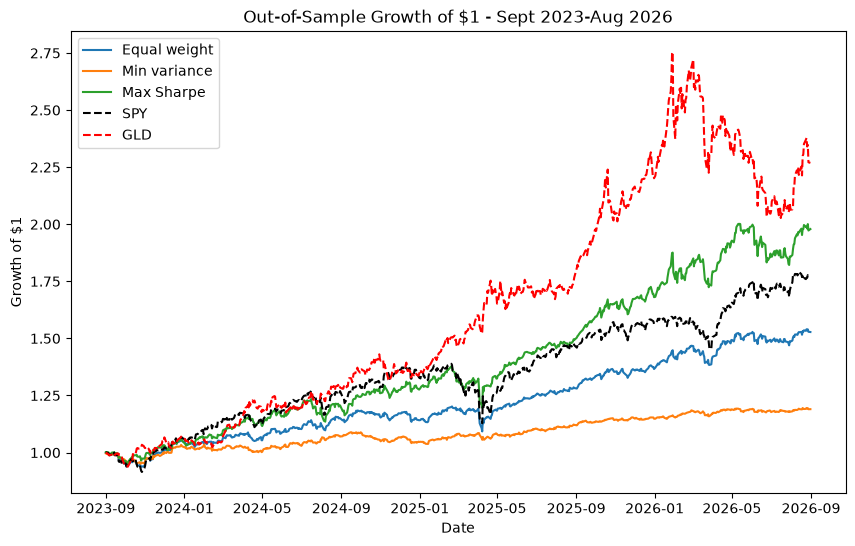

In [59]:
plt.figure(figsize=(10, 6))

for name, w in portfolios.items():
    growth = (1 + test @ w).cumprod()
    plt.plot(growth.index, growth, label=name)
 
spy_growth = (1 + test["SPY"]).cumprod()
plt.plot(spy_growth.index, spy_growth, label="SPY", linestyle="--", color="black")
GLD = (1 + test["GLD"]).cumprod()
plt.plot(GLD.index, GLD, label="GLD", linestyle="--", color = "red")
plt.title("Out-of-Sample Growth of $1 - Sept 2023-Aug 2026")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.savefig("../data/portfolio_growth.png", dpi = 150)
plt.show()

In [60]:
rf

0.04396026625614192

In [61]:
import yfinance as yf

irx = yf.download("^IRX", start="2023-09-01", end="2026-09-01", threads=False)
rf_test = irx["Close"].mean().item() / 100

irx_full = yf.download("^IRX", start="2016-09-01", end="2026-09-01", threads=False)
rf_full = irx_full["Close"].mean().item() / 100

print("Test-period average:", rf_test)
print("Full-decade average:", rf_full)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Test-period average: 0.04396026625614192
Full-decade average: 0.023810338498959603
